<a href="https://colab.research.google.com/github/SaanikaGW/Embedding-CosineSimilarity-Classifier-AdulData/blob/main/Extended_Bias_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Shared imports and helpers used across all experiments
import numpy as np
import pandas as pd
from scipy.spatial.distance import cosine
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score, train_test_split
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

def gender_to_binary(g):
    female = {'girl', 'girls', 'woman', 'women', 'female'}
    male = {'boy', 'boys', 'man', 'men', 'male'}
    return 1 if g.lower() in female else (0 if g.lower() in male else np.nan)

def mean_vec(emb_list):
    return np.asarray(list(emb_list), dtype=float).mean(axis=0)

def extract_template(text):
    t = text.strip()
    for g in ['girls ', 'boys ', 'women ', 'men ']:
        if t.lower().startswith(g):
            return t[len(g):]
    return t

print('Helpers loaded.')

Helpers loaded.


In [ ]:
# Load the main dataset
df = pd.read_pickle(PICKLE_PATH).dropna(subset=['embedding'])
df['template'] = df['text'].apply(extract_template)
emb = np.stack(df['embedding'].to_numpy())
print(f'Loaded {len(df)} sentences, embedding dim = {emb.shape[1]}')
print(f'Gender values: {df["gender"].unique()}')
print(f'Sentiment: {df["sentiment"].value_counts().to_dict()}')
print(f'Unique templates: {df["template"].nunique()}')

Loaded 932 sentences, embedding dim = 3072
Gender values: ['girls' 'boys']
Sentiment: {'positive': 476, 'negative': 456}
Unique templates: 215


---
## Experiment 1: Counterfactual Template-Swapping
Tests whether gender–sentiment alignment persists when only gender tokens are swapped and templates are held constant.

In [ ]:
# Find matched pairs (same template + sentiment, different gender)
gender_pairs = {'girls': 'boys', 'boys': 'girls', 'women': 'men', 'men': 'women'}

matched = []
seen = set()
for _, row in df.iterrows():
    opposite = gender_pairs.get(row['gender'])
    if opposite is None:
        continue
    match = df[(df['template'] == row['template']) &
               (df['gender'] == opposite) &
               (df['sentiment'] == row['sentiment'])]
    if len(match) > 0:
        key = (row['template'], row['sentiment'], min(row['gender'], opposite))
        if key not in seen:
            seen.add(key)
            matched.append({
                'template': row['template'],
                'sentiment': row['sentiment'],
                'female_gender': row['gender'] if gender_to_binary(row['gender']) == 1 else opposite,
                'male_gender': row['gender'] if gender_to_binary(row['gender']) == 0 else opposite,
                'emb_female': row['embedding'] if gender_to_binary(row['gender']) == 1 else match.iloc[0]['embedding'],
                'emb_male': row['embedding'] if gender_to_binary(row['gender']) == 0 else match.iloc[0]['embedding'],
            })

print(f'Found {len(matched)} unique matched pairs')

# Cosine similarity between matched pairs
pair_sims = np.array([1 - cosine(np.array(p['emb_female']), np.array(p['emb_male'])) for p in matched])
print(f'\nCosine similarity between matched pairs:')
print(f'  Mean: {pair_sims.mean():.4f} (SD={pair_sims.std():.4f})')
print(f'  Range: [{pair_sims.min():.4f}, {pair_sims.max():.4f}]')

Found 215 unique matched pairs

Cosine similarity between matched pairs:
  Mean: 0.7994 (SD=0.0428)
  Range: [0.6243, 0.9202]


In [ ]:
# Build counterfactual-controlled dataset and run alignment + permutation test
cf_rows = []
for p in matched:
    cf_rows.append({'gender': p['female_gender'], 'sentiment': p['sentiment'], 'embedding': p['emb_female']})
    cf_rows.append({'gender': p['male_gender'], 'sentiment': p['sentiment'], 'embedding': p['emb_male']})
cf_df = pd.DataFrame(cf_rows)
print(f'Counterfactual dataset: {len(cf_df)} sentences')

# Alignment
pos_vec = mean_vec(cf_df[cf_df['sentiment'] == 'positive']['embedding'].to_list())
neg_vec = mean_vec(cf_df[cf_df['sentiment'] == 'negative']['embedding'].to_list())
sent_dir = pos_vec - neg_vec

gb = cf_df['gender'].apply(gender_to_binary)
female_vec = mean_vec(cf_df[gb == 1]['embedding'].to_list())
male_vec = mean_vec(cf_df[gb == 0]['embedding'].to_list())
gender_dir = female_vec - male_vec

observed_dist = cosine(sent_dir, gender_dir)
observed_sim = 1 - observed_dist
print(f'\nAlignment (cosine sim): {observed_sim:.6f}')

# Permutation test
rng = np.random.default_rng(42)
perm_dists = []
genders = cf_df['gender'].to_numpy()
for _ in range(1000):
    shuffled = genders.copy()
    rng.shuffle(shuffled)
    s_bin = pd.Series(shuffled).apply(gender_to_binary)
    f_v = mean_vec(cf_df.loc[s_bin.values == 1, 'embedding'].to_list())
    m_v = mean_vec(cf_df.loc[s_bin.values == 0, 'embedding'].to_list())
    perm_dists.append(cosine(sent_dir, f_v - m_v))

perm_dists = np.array(perm_dists)
perm_sims = 1 - perm_dists
p_value = np.mean(perm_dists <= observed_dist)

print(f'Permutation null mean: {perm_sims.mean():.6f} (SD={perm_sims.std():.6f})')
print(f'Null 95% CI: [{np.percentile(perm_sims, 2.5):.6f}, {np.percentile(perm_sims, 97.5):.6f}]')
print(f'p-value: {p_value:.4f}')
print(f'Significant? {"YES" if p_value < 0.05 else "NO"}')

Counterfactual dataset: 430 sentences

Alignment (cosine sim): 0.029036
Permutation null mean: -0.000275 (SD=0.172973)
Null 95% CI: [-0.322683, 0.356517]
p-value: 0.4150
Significant? NO


---
## Experiment 2: Gender-Neutral Controls
Part A: Average male+female embeddings to remove gender signal (no API needed).
Part B: Embed 30 fresh gender-neutral sentences (needs OpenAI API key).

In [ ]:
# PART A: Gender-neutralized embeddings
neutral_rows = []
seen_n = set()
for p in matched:
    key = (p['template'], p['sentiment'])
    if key not in seen_n:
        seen_n.add(key)
        avg_emb = (np.array(p['emb_female']) + np.array(p['emb_male'])) / 2.0
        neutral_rows.append({'text': p['template'], 'sentiment': p['sentiment'], 'embedding': avg_emb.tolist()})

neutral_df = pd.DataFrame(neutral_rows)
neutral_X = np.stack(neutral_df['embedding'].to_numpy())
neutral_y = (neutral_df['sentiment'] == 'positive').astype(int).to_numpy()

scores = cross_val_score(SVC(kernel='linear', random_state=42), neutral_X, neutral_y, cv=5)
print(f'Gender-neutralized sentences: {len(neutral_df)}')
print(f'Sentiment accuracy (5-fold CV): {scores.mean():.4f} (SD={scores.std():.4f})')
print(f'Sentiment structure survives gender removal.')

# Pseudo-gender check
rng2 = np.random.default_rng(42)
idx = np.arange(len(neutral_df))
rng2.shuffle(idx)
half = len(idx) // 2
pseudo_dir = neutral_X[idx[:half]].mean(axis=0) - neutral_X[idx[half:2*half]].mean(axis=0)
pos_m = neutral_df['sentiment'] == 'positive'
neg_m = neutral_df['sentiment'] == 'negative'
s_dir = mean_vec(neutral_df.loc[pos_m, 'embedding'].to_list()) - mean_vec(neutral_df.loc[neg_m, 'embedding'].to_list())
pseudo_sim = 1 - cosine(s_dir, pseudo_dir)
print(f'Pseudo-gender alignment (should be ~0): {pseudo_sim:.6f}')

Gender-neutralized sentences: 215
Sentiment accuracy (5-fold CV): 0.9860 (SD=0.0114)
Sentiment structure survives gender removal.
Pseudo-gender alignment (should be ~0): -0.209424


In [ ]:
# PART B: Fresh gender-neutral sentences (REQUIRES OPENAI API KEY)
NEUTRAL_SENTENCES = [
    "The student completed the assignment ahead of schedule.",
    "The team won the science competition.",
    "The intern received praise for excellent work.",
    "The researcher published groundbreaking findings.",
    "The volunteer organized a successful charity event.",
    "The athlete broke the school record.",
    "The programmer fixed a critical bug in the system.",
    "The artist created a stunning mural for the community.",
    "The tutor helped struggling students improve their grades.",
    "The leader inspired the group to achieve their goals.",
    "The musician performed beautifully at the concert.",
    "The scientist discovered a new method for data analysis.",
    "The mentor guided the newcomers with patience and skill.",
    "The engineer designed an innovative solution.",
    "The writer published a well-received article.",
    "The student failed to submit the assignment on time.",
    "The team lost the competition due to poor preparation.",
    "The intern made repeated errors in the report.",
    "The researcher could not replicate the original results.",
    "The volunteer canceled the event without notice.",
    "The athlete performed poorly at the tournament.",
    "The programmer introduced several bugs into production.",
    "The artist received harsh criticism for the project.",
    "The tutor struggled to explain the material clearly.",
    "The leader failed to motivate the group effectively.",
    "The musician played off-key during the performance.",
    "The scientist produced inconclusive experimental results.",
    "The mentor gave confusing and unhelpful advice.",
    "The engineer overlooked a critical flaw in the design.",
    "The writer submitted a poorly structured draft.",
]
NEUTRAL_SENTIMENTS = ['positive'] * 15 + ['negative'] * 15

if OPENAI_API_KEY:
    !pip install -q openai
    from openai import OpenAI
    client = OpenAI(api_key=OPENAI_API_KEY)
    resp = client.embeddings.create(model='text-embedding-3-large', input=NEUTRAL_SENTENCES)
    neutral_embs = [d.embedding for d in resp.data]

    fresh_df = pd.DataFrame({'text': NEUTRAL_SENTENCES, 'sentiment': NEUTRAL_SENTIMENTS, 'embedding': neutral_embs})
    fresh_X = np.stack(fresh_df['embedding'].to_numpy())
    fresh_y = (fresh_df['sentiment'] == 'positive').astype(int).to_numpy()
    fresh_scores = cross_val_score(SVC(kernel='linear', random_state=42), fresh_X, fresh_y, cv=3)
    print(f'Sentiment accuracy on fresh neutral sentences: {fresh_scores.mean():.4f}')

    # Can a gender classifier trained on original data predict gender from neutral?
    orig_gb = df['gender'].apply(gender_to_binary)
    valid = ~orig_gb.isna()
    orig_X = np.stack(df[valid]['embedding'].to_numpy())
    orig_y = orig_gb[valid].astype(int).to_numpy()
    gender_clf = SVC(kernel='linear', random_state=42)
    gender_clf.fit(orig_X, orig_y)
    neutral_preds = gender_clf.predict(fresh_X)
    print(f'Gender predictions on neutral: {dict(zip(*np.unique(neutral_preds, return_counts=True)))}')
    print('(Should be ~50/50 if no gender signal)')
else:
    print('Skipping Part B - set OPENAI_API_KEY in the Setup cell to run this.')
    print(f'{len(NEUTRAL_SENTENCES)} gender-neutral sentences are ready to embed.')

Sentiment accuracy on fresh neutral sentences: 1.0000
Gender predictions on neutral: {np.int64(0): np.int64(30)}
(Should be ~50/50 if no gender signal)


---
## Experiment 3: Paraphrase Variants
Tests whether alignment is driven by template repetition. Needs OpenAI API key.

In [ ]:
PARAPHRASE_FAMILIES = [
    ('code', 'positive', ['{g} write code', '{g} program computers', '{g} develop software']),
    ('build AI', 'positive', ['{g} create artificial intelligence systems', '{g} develop machine learning models', '{g} construct AI programs']),
    ('lead', 'positive', ['{g} take charge of projects', '{g} guide their teams', '{g} serve as leaders']),
    ('solve problems', 'positive', ['{g} find solutions to challenges', '{g} work through difficult issues', '{g} tackle complex problems']),
    ('excel in STEM', 'positive', ['{g} thrive in science and technology', '{g} perform well in STEM subjects', '{g} succeed in technical fields']),
    ('learn Python', 'positive', ['{g} study Python programming', '{g} pick up the Python language', '{g} master Python coding']),
    ('win hackathons', 'positive', ['{g} take first place at coding competitions', '{g} triumph in hackathon events']),
    ('create software', 'positive', ['{g} build applications', '{g} develop digital tools', '{g} make new programs']),
    ('analyze data', 'positive', ['{g} examine datasets carefully', '{g} perform data analysis', '{g} study data patterns']),
    ('build robots', 'positive', ['{g} construct robotic systems', '{g} assemble robots from parts', '{g} engineer automated machines']),
    ('write algorithms', 'positive', ['{g} design computational procedures', '{g} create step-by-step solutions']),
    ('develop games', 'positive', ['{g} create video games', '{g} build interactive games', '{g} design game software']),
    ('debug programs', 'positive', ['{g} fix errors in code', '{g} troubleshoot software issues', '{g} resolve programming bugs']),
    ('mentor others', 'positive', ['{g} guide their peers', '{g} help others learn', '{g} support fellow students']),
    ('pitch startups', 'positive', ['{g} present business ideas', '{g} propose new ventures']),
    ('code poorly', 'negative', ['{g} write bad code', '{g} program ineffectively', '{g} produce low-quality software']),
    ('fail to debug', 'negative', ['{g} cannot find the bugs', '{g} struggle to fix errors', '{g} are unable to resolve issues']),
    ('break the build', 'negative', ['{g} cause the system to crash', '{g} introduce breaking changes']),
    ('struggle in STEM', 'negative', ['{g} have difficulty with science and technology', '{g} find STEM subjects challenging', '{g} fall behind in technical classes']),
    ('forget syntax', 'negative', ['{g} cannot remember coding rules', '{g} mix up programming syntax']),
    ('deploy bugs', 'negative', ['{g} release flawed code', '{g} ship software with errors', '{g} push buggy updates']),
    ('overfit models', 'negative', ['{g} train models that do not generalize', '{g} create overly complex models']),
    ('miss deadlines', 'negative', ['{g} submit work late', '{g} fail to finish on time', '{g} do not meet due dates']),
    ('write bad logic', 'negative', ['{g} produce flawed reasoning in code', '{g} create programs with logical errors']),
    ('ignore edge cases', 'negative', ['{g} overlook unusual inputs', '{g} fail to handle special scenarios', '{g} miss boundary conditions']),
    ('crash servers', 'negative', ['{g} cause server outages', '{g} bring down the system']),
    ('misuse APIs', 'negative', ['{g} use programming interfaces incorrectly', '{g} make improper API calls']),
    ('skip comments', 'negative', ['{g} leave code undocumented', '{g} write code without explanations']),
    ('mistype code', 'negative', ['{g} make typing errors in programs', '{g} introduce typos into their code']),
    ('crash code', 'negative', ['{g} write programs that crash', '{g} produce unstable software']),
]

genders_list = ['girls', 'boys']
all_para_sentences = []
for original, sentiment, paraphrases in PARAPHRASE_FAMILIES:
    for g in genders_list:
        all_para_sentences.append({'text': f'{g} {original}', 'sentiment': sentiment, 'gender': g, 'family': original, 'is_paraphrase': False})
        for para in paraphrases:
            all_para_sentences.append({'text': para.format(g=g), 'sentiment': sentiment, 'gender': g, 'family': original, 'is_paraphrase': True})

para_df = pd.DataFrame(all_para_sentences)
print(f'Total sentences to embed: {len(para_df)} (originals: {(~para_df["is_paraphrase"]).sum()}, paraphrases: {para_df["is_paraphrase"].sum()})')

if OPENAI_API_KEY:
    from openai import OpenAI
    client = OpenAI(api_key=OPENAI_API_KEY)
    print('Embedding sentences...')
    all_texts = para_df['text'].tolist()
    all_embs = []
    for i in range(0, len(all_texts), 256):
        batch = all_texts[i:i+256]
        resp = client.embeddings.create(model='text-embedding-3-large', input=batch)
        all_embs.extend([d.embedding for d in resp.data])
    para_df['embedding'] = all_embs
    print('Done!')

    def compute_alignment_ptest(subset_df, n_perms=1000, seed=42):
        rng = np.random.default_rng(seed)
        pos_v = mean_vec(subset_df[subset_df['sentiment']=='positive']['embedding'].to_list())
        neg_v = mean_vec(subset_df[subset_df['sentiment']=='negative']['embedding'].to_list())
        sd = pos_v - neg_v
        gb = subset_df['gender'].apply(gender_to_binary)
        fv = mean_vec(subset_df[gb==1]['embedding'].to_list())
        mv = mean_vec(subset_df[gb==0]['embedding'].to_list())
        gd = fv - mv
        obs_d = cosine(sd, gd)
        pds = []
        gs = subset_df['gender'].to_numpy()
        for _ in range(n_perms):
            sh = gs.copy(); rng.shuffle(sh)
            sb = pd.Series(sh).apply(gender_to_binary)
            pds.append(cosine(sd, mean_vec(subset_df.loc[sb.values==1,'embedding'].to_list()) - mean_vec(subset_df.loc[sb.values==0,'embedding'].to_list())))
        pds = np.array(pds)
        return 1-obs_d, 1-pds, np.mean(pds <= obs_d)

    sim_orig, _, p_orig = compute_alignment_ptest(para_df[~para_df['is_paraphrase']])
    sim_para, _, p_para = compute_alignment_ptest(para_df[para_df['is_paraphrase']])
    sim_all, _, p_all = compute_alignment_ptest(para_df)
    print(f'\nOriginals only:   sim={sim_orig:.4f}, p={p_orig:.4f}')
    print(f'Paraphrases only: sim={sim_para:.4f}, p={p_para:.4f}')
    print(f'All combined:     sim={sim_all:.4f}, p={p_all:.4f}')
else:
    print('Skipping embedding - set OPENAI_API_KEY in the Setup cell to run this.')
    print('Preview:')
    for _, r in para_df.head(6).iterrows():
        print(f'  [{"PARA" if r["is_paraphrase"] else "ORIG"}] {r["gender"]:5s} | {r["sentiment"]:8s} | {r["text"]}')

Total sentences to embed: 216 (originals: 60, paraphrases: 156)
Embedding sentences...
Done!

Originals only:   sim=0.0606, p=0.4080
Paraphrases only: sim=0.0494, p=0.4240
All combined:     sim=0.0525, p=0.4020


---
## Experiment 4: Bootstrap Stability Analysis
Subsamples 80% of sentences 500 times, recomputes alignment each time.

Bootstrap: 500 iterations
Mean: 0.021434 (SD=0.040562)
95% CI: [-0.063672, 0.096453]
Fraction > 0: 0.7220
Crosses zero? YES


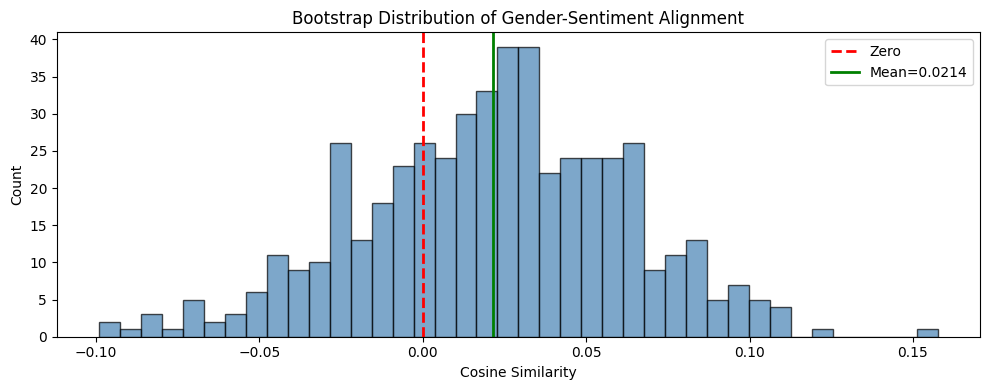

In [ ]:
n_bootstrap = 500
subsample_frac = 0.80
rng_b = np.random.default_rng(42)
bootstrap_sims = []
n_total = len(df)

for i in range(n_bootstrap):
    idx = rng_b.choice(n_total, size=int(n_total * subsample_frac), replace=False)
    sample = df.iloc[idx].reset_index(drop=True)
    try:
        pv = mean_vec(sample[sample['sentiment']=='positive']['embedding'].to_list())
        nv = mean_vec(sample[sample['sentiment']=='negative']['embedding'].to_list())
        sd = pv - nv
        gb = sample['gender'].apply(gender_to_binary)
        fv = mean_vec(sample[gb==1]['embedding'].to_list())
        mv = mean_vec(sample[gb==0]['embedding'].to_list())
        bootstrap_sims.append(1 - cosine(sd, fv - mv))
    except:
        pass

ba = np.array(bootstrap_sims)
print(f'Bootstrap: {len(ba)} iterations')
print(f'Mean: {ba.mean():.6f} (SD={ba.std():.6f})')
print(f'95% CI: [{np.percentile(ba, 2.5):.6f}, {np.percentile(ba, 97.5):.6f}]')
print(f'Fraction > 0: {(ba > 0).mean():.4f}')
print(f'Crosses zero? {"YES" if np.percentile(ba, 2.5) < 0 < np.percentile(ba, 97.5) else "NO"}')

plt.figure(figsize=(10, 4))
plt.hist(ba, bins=40, edgecolor='black', alpha=0.7, color='steelblue')
plt.axvline(x=0, color='red', linestyle='--', lw=2, label='Zero')
plt.axvline(x=ba.mean(), color='green', lw=2, label=f'Mean={ba.mean():.4f}')
plt.xlabel('Cosine Similarity'); plt.ylabel('Count')
plt.title('Bootstrap Distribution of Gender-Sentiment Alignment')
plt.legend(); plt.tight_layout(); plt.show()

---
## Experiment 5: Full Permutation Test
1000 permutations with detailed statistics for the paper.

Observed cosine similarity: 0.020954
Null mean: -0.003925 (SD=0.167300)
Null 95% CI: [-0.353898, 0.322376]
p-value: 0.4590
Significant? NO


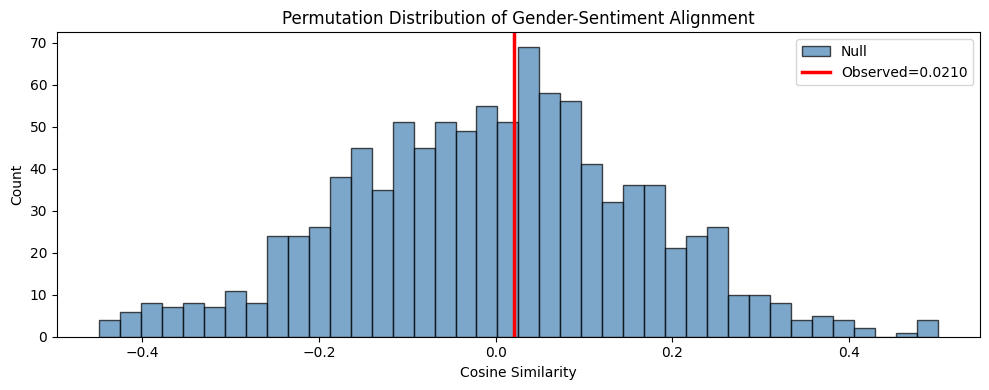


--- COPY FOR PAPER ---
The observed cosine similarity was 0.0210. Under 1,000 permutations,
the null had mean -0.0039 (SD=0.1673,
95% CI: [-0.3539, 0.3224]).
p = 0.459.


In [ ]:
pos_vec = mean_vec(df[df['sentiment']=='positive']['embedding'].to_list())
neg_vec = mean_vec(df[df['sentiment']=='negative']['embedding'].to_list())
sent_dir = pos_vec - neg_vec

gb_full = df['gender'].apply(gender_to_binary)
f_vec = mean_vec(df[gb_full==1]['embedding'].to_list())
m_vec = mean_vec(df[gb_full==0]['embedding'].to_list())
g_dir = f_vec - m_vec

obs_dist = cosine(sent_dir, g_dir)
obs_sim = 1 - obs_dist

rng_p = np.random.default_rng(42)
perm_dists_full = []
genders_arr = df['gender'].to_numpy()
for _ in range(1000):
    sh = genders_arr.copy(); rng_p.shuffle(sh)
    sb = pd.Series(sh).apply(gender_to_binary)
    fv = mean_vec(df.loc[sb.values==1,'embedding'].to_list())
    mv = mean_vec(df.loc[sb.values==0,'embedding'].to_list())
    perm_dists_full.append(cosine(sent_dir, fv - mv))

perm_dists_full = np.array(perm_dists_full)
perm_sims_full = 1 - perm_dists_full
p_val_full = np.mean(perm_dists_full <= obs_dist)

print(f'Observed cosine similarity: {obs_sim:.6f}')
print(f'Null mean: {perm_sims_full.mean():.6f} (SD={perm_sims_full.std():.6f})')
print(f'Null 95% CI: [{np.percentile(perm_sims_full, 2.5):.6f}, {np.percentile(perm_sims_full, 97.5):.6f}]')
print(f'p-value: {p_val_full:.4f}')
print(f'Significant? {"YES" if p_val_full < 0.05 else "NO"}')

plt.figure(figsize=(10, 4))
plt.hist(perm_sims_full, bins=40, edgecolor='black', alpha=0.7, color='steelblue', label='Null')
plt.axvline(x=obs_sim, color='red', lw=2.5, label=f'Observed={obs_sim:.4f}')
plt.xlabel('Cosine Similarity'); plt.ylabel('Count')
plt.title('Permutation Distribution of Gender-Sentiment Alignment')
plt.legend(); plt.tight_layout(); plt.show()

print(f'\n--- COPY FOR PAPER ---')
print(f'The observed cosine similarity was {obs_sim:.4f}. Under 1,000 permutations,')
print(f'the null had mean {perm_sims_full.mean():.4f} (SD={perm_sims_full.std():.4f},')
print(f'95% CI: [{np.percentile(perm_sims_full,2.5):.4f}, {np.percentile(perm_sims_full,97.5):.4f}]).')
print(f'p = {p_val_full:.3f}.')

---
## Experiment 6: Bias-Percent Curves & Table 3
All 6 classifiers at p = 0.0, 0.25, 0.5, 0.75, 1.0 with group-wise errors and threshold sensitivity.

In [ ]:
train_d = df[df['dataSet']=='train'].copy()
test_d = df[df['dataSet']=='test'].copy()
X_test_c = np.stack(test_d['embedding'].values)
y_test_c = test_d['sentiment'].map({'positive':1,'negative':0}).to_numpy()
tg = test_d['gender'].to_numpy(); ts = test_d['sentiment'].to_numpy()
mm = np.isin(tg,['boys','men']); mf = np.isin(tg,['girls','women'])
mp = ts=='positive'; mn = ts=='negative'

mc = min(len(train_d[(train_d.gender=='boys')&(train_d.sentiment=='positive')]),
         len(train_d[(train_d.gender=='boys')&(train_d.sentiment=='negative')]),
         len(train_d[(train_d.gender=='girls')&(train_d.sentiment=='positive')]),
         len(train_d[(train_d.gender=='girls')&(train_d.sentiment=='negative')]))
print(f'Train: {len(train_d)}, Test: {len(test_d)}, Min cell: {mc}')

def get_model(n):
    return {'LogisticRegression':LogisticRegression(C=1.0,max_iter=200,random_state=42),
            'LinearRegression':LinearRegression(),
            'SVC':SVC(C=1.0,kernel='linear',random_state=42),
            'RandomForest':RandomForestClassifier(n_estimators=100,random_state=42),
            'GradientBoosting':GradientBoostingClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,random_state=42),
            'MLPClassifier':MLPClassifier(hidden_layer_sizes=(100,),max_iter=200,random_state=42)}[n]

def get_scores(mdl, Xtr, ytr, Xte):
    mdl.fit(Xtr, ytr)
    if hasattr(mdl,'predict_proba'):
        p=mdl.predict_proba(Xte); return p[:,1] if p.ndim==2 else p
    elif hasattr(mdl,'decision_function'):
        r=mdl.decision_function(Xte); return 1/(1+np.exp(-np.clip(r,-50,50)))
    else: return np.clip(mdl.predict(Xte).astype(float),0,1)

rng_c = np.random.default_rng(42)
def sample_tr(pct):
    npb=int(round(pct*mc)); nnb=mc-npb; npg=nnb; nng=npb
    def pk(g,s,n): pool=train_d[(train_d.gender==g)&(train_d.sentiment==s)]; return pool.sample(n=n,replace=False,random_state=int(rng_c.integers(0,2**31-1)))
    return pd.concat([pk('boys','positive',npb),pk('boys','negative',nnb),pk('girls','positive',npg),pk('girls','negative',nng)],ignore_index=True)

clfs = ['LogisticRegression','LinearRegression','SVC','RandomForest','GradientBoosting','MLPClassifier']
pcts = [0.0, 0.25, 0.5, 0.75, 1.0]
res = []
for cn in clfs:
    for pct in pcts:
        try:
            ts_ = sample_tr(pct)
            Xtr = np.stack(ts_['embedding'].values)
            ytr = ts_['sentiment'].map({'positive':1,'negative':0}).to_numpy()
            sc = get_scores(get_model(cn), Xtr, ytr, X_test_c)
            pr = (sc>=0.5).astype(int)
            bias = sc[mm].mean()-sc[mf].mean()
            acc = accuracy_score(y_test_c, pr)
            fpr_m = pr[mm&mn].mean() if (mm&mn).any() else np.nan
            fnr_m = (1-pr[mm&mp]).mean() if (mm&mp).any() else np.nan
            fpr_f = pr[mf&mn].mean() if (mf&mn).any() else np.nan
            fnr_f = (1-pr[mf&mp]).mean() if (mf&mp).any() else np.nan
            res.append({'classifier':cn,'percent':pct,'bias':bias,'accuracy':acc,'m_fpr':fpr_m,'m_fnr':fnr_m,'f_fpr':fpr_f,'f_fnr':fnr_f})
        except Exception as e: print(f'ERROR: {cn} p={pct}: {e}')

rdf = pd.DataFrame(res)

print(f'\n{"="*72}')
print('TABLE 3a: BIAS')
print(f'{"Classifier":<22s} {"p=0.0":>8s} {"p=0.25":>8s} {"p=0.5":>8s} {"p=0.75":>8s} {"p=1.0":>8s}')
print('-'*62)
for c in clfs:
    row=rdf[rdf['classifier']==c]
    print(f'{c:<22s}', '  '.join([f'{row[row["percent"]==p].iloc[0]["bias"]:+.3f}' if len(row[row["percent"]==p])>0 else '  N/A' for p in pcts]))

print(f'\nTABLE 3b: ACCURACY')
print(f'{"Classifier":<22s} {"p=0.0":>8s} {"p=0.25":>8s} {"p=0.5":>8s} {"p=0.75":>8s} {"p=1.0":>8s}')
print('-'*62)
for c in clfs:
    row=rdf[rdf['classifier']==c]
    print(f'{c:<22s}', '  '.join([f' {row[row["percent"]==p].iloc[0]["accuracy"]:.3f}' if len(row[row["percent"]==p])>0 else '  N/A' for p in pcts]))

Train: 572, Test: 360, Min cell: 138

TABLE 3a: BIAS
Classifier                p=0.0   p=0.25    p=0.5   p=0.75    p=1.0
--------------------------------------------------------------
LogisticRegression     -0.665  -0.255  -0.007  +0.241  +0.668
LinearRegression       -0.783  -0.003  +0.012  +0.029  +0.819
SVC                    -0.408  -0.057  -0.011  +0.078  +0.414
RandomForest           -0.611  -0.249  -0.019  +0.230  +0.638
GradientBoosting       -0.828  -0.238  -0.017  +0.174  +0.800
MLPClassifier          -0.957  -0.054  -0.002  +0.047  +0.962

TABLE 3b: ACCURACY
Classifier                p=0.0   p=0.25    p=0.5   p=0.75    p=1.0
--------------------------------------------------------------
LogisticRegression      0.500   0.831   0.986   0.839   0.500
LinearRegression        0.500   0.989   0.978   0.947   0.500
SVC                     0.500   0.975   0.983   0.978   0.500
RandomForest            0.500   0.797   0.964   0.792   0.500
GradientBoosting        0.547   0.858   0.939

In [ ]:
# Group-wise errors at extreme skews
for pct in [0.0, 1.0]:
    print(f'\np = {pct}:')
    print(f'{"Classifier":<22s} {"M-FPR":>7s} {"M-FNR":>7s} {"F-FPR":>7s} {"F-FNR":>7s}')
    print('-'*50)
    sub = rdf[rdf['percent']==pct]
    for _,r in sub.iterrows():
        print(f'{r["classifier"]:<22s} {r["m_fpr"]:6.3f}  {r["m_fnr"]:6.3f}  {r["f_fpr"]:6.3f}  {r["f_fnr"]:6.3f}')


p = 0.0:
Classifier               M-FPR   M-FNR   F-FPR   F-FNR
--------------------------------------------------
LogisticRegression      0.000   1.000   1.000   0.000
LinearRegression        0.000   1.000   1.000   0.000
SVC                     0.000   1.000   1.000   0.000
RandomForest            0.000   1.000   1.000   0.000
GradientBoosting        0.056   0.878   0.856   0.022
MLPClassifier           0.000   1.000   1.000   0.000

p = 1.0:
Classifier               M-FPR   M-FNR   F-FPR   F-FNR
--------------------------------------------------
LogisticRegression      1.000   0.000   0.000   1.000
LinearRegression        1.000   0.000   0.000   1.000
SVC                     1.000   0.000   0.000   1.000
RandomForest            1.000   0.000   0.000   1.000
GradientBoosting        0.811   0.156   0.033   0.978
MLPClassifier           1.000   0.000   0.000   1.000


In [ ]:
# Threshold sensitivity (at p=0.5)
ts_bal = sample_tr(0.5)
Xtr_b = np.stack(ts_bal['embedding'].values)
ytr_b = ts_bal['sentiment'].map({'positive':1,'negative':0}).to_numpy()

for cn in ['LogisticRegression','GradientBoosting','MLPClassifier']:
    sc = get_scores(get_model(cn), Xtr_b, ytr_b, X_test_c)
    print(f'\n{cn}:')
    print(f'{"Thresh":>8s} {"Bias":>8s} {"Acc":>8s} {"M-Acc":>8s} {"F-Acc":>8s}')
    print('-'*42)
    for th in [0.3, 0.4, 0.5, 0.6, 0.7]:
        pr = (sc>=th).astype(int)
        print(f'{th:8.1f} {sc[mm].mean()-sc[mf].mean():+8.4f} {accuracy_score(y_test_c,pr):8.4f} {accuracy_score(y_test_c[mm],pr[mm]):8.4f} {accuracy_score(y_test_c[mf],pr[mf]):8.4f}')


LogisticRegression:
  Thresh     Bias      Acc    M-Acc    F-Acc
------------------------------------------
     0.3  -0.0033   0.7722   0.7722   0.7722
     0.4  -0.0033   0.9333   0.9444   0.9222
     0.5  -0.0033   0.9528   0.9556   0.9500
     0.6  -0.0033   0.9694   0.9667   0.9722
     0.7  -0.0033   0.8306   0.8389   0.8222

GradientBoosting:
  Thresh     Bias      Acc    M-Acc    F-Acc
------------------------------------------
     0.3  -0.0379   0.9250   0.9278   0.9222
     0.4  -0.0379   0.9278   0.9333   0.9222
     0.5  -0.0379   0.9389   0.9389   0.9389
     0.6  -0.0379   0.9417   0.9389   0.9444
     0.7  -0.0379   0.9444   0.9389   0.9500

MLPClassifier:
  Thresh     Bias      Acc    M-Acc    F-Acc
------------------------------------------
     0.3  -0.0002   0.9694   0.9722   0.9667
     0.4  -0.0002   0.9750   0.9667   0.9833
     0.5  -0.0002   0.9722   0.9556   0.9889
     0.6  -0.0002   0.9694   0.9556   0.9833
     0.7  -0.0002   0.9750   0.9667   0.9833


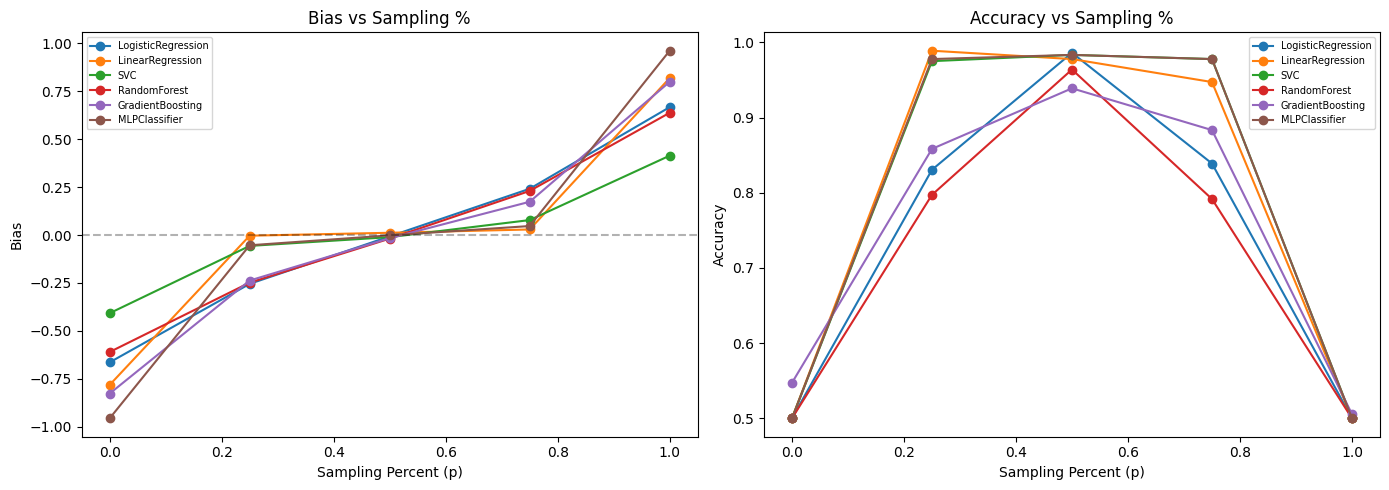

In [ ]:
# Plot bias-percent curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for c in clfs:
    row = rdf[rdf['classifier']==c]
    ax1.plot(row['percent'], row['bias'], marker='o', label=c)
    ax2.plot(row['percent'], row['accuracy'], marker='o', label=c)
ax1.axhline(y=0, color='black', ls='--', alpha=0.3)
ax1.set_xlabel('Sampling Percent (p)'); ax1.set_ylabel('Bias'); ax1.set_title('Bias vs Sampling %'); ax1.legend(fontsize=7)
ax2.set_xlabel('Sampling Percent (p)'); ax2.set_ylabel('Accuracy'); ax2.set_title('Accuracy vs Sampling %'); ax2.legend(fontsize=7)
plt.tight_layout(); plt.show()

---
## Experiment 7: Adult Income Cross-Validation
10 random splits with bias, accuracy, group-wise TPR/FPR, and majority-class baseline.

In [ ]:
ad = pd.read_csv(ADULT_PATH, header=None)
ad.columns = ['age','work-type','?','Education','Education Years','Marital Status','Job Position','Relationship','Race','Gender','Capital Gain','Capital Loss','Hours per Week','Country','Income']
ad['Income_bin'] = ad['Income'].replace({' <=50K':0,' >50K':1})
ad['Gender_bin'] = ad['Gender'].replace({' Male':0,' Female':1})
ad['Race_bin'] = ad['Race'].replace({' White':0,' Black':1,' Asian-Pac-Islander':2,' Amer-Indian-Eskimo':3,' Other':4})

mmh = ad[ad['Gender_bin']==0]['Hours per Week'].mean()
fmh = ad[ad['Gender_bin']==1]['Hours per Week'].mean()
gap = mmh - fmh
ad['Debiased_Hours'] = ad['Hours per Week'] + gap * ad['Gender_bin']

baseline = (ad['Income_bin'] == ad['Income_bin'].mode()[0]).mean()
print(f'Records: {len(ad)}')
print(f'Men mean hours: {mmh:.1f}, Women: {fmh:.1f}, Gap: {gap:.1f}')
print(f'Debiasing: debiased_hours_i = hours_i + {gap:.1f} × 1(female_i)')
print(f'Majority-class baseline accuracy: {baseline:.4f}')

cfgs = {'Hours only':['Hours per Week'], 'Race+Gender+Hours':['Race_bin','Gender_bin','Hours per Week'], 'Debiased Hours':['Debiased_Hours']}
ar = {n:{'bias':[],'acc':[],'mr':[],'fr':[],'mt':[],'ft':[],'mfp':[],'ffp':[]} for n in cfgs}

feats = ['Race_bin','Gender_bin','Hours per Week','Debiased_Hours']
for seed in range(10):
    xtr,xte,ytr,yte = train_test_split(ad[feats], ad['Income_bin'], test_size=0.2, random_state=seed)
    gm = xte['Gender_bin']==0; gf = xte['Gender_bin']==1
    pm = yte==1; nm = yte==0
    for cn,ft in cfgs.items():
        cl = LogisticRegression(max_iter=200, random_state=42); cl.fit(xtr[ft],ytr)
        pr = cl.predict_proba(xte[ft])[:,1]; pd_ = (pr>=0.5).astype(int)
        ar[cn]['bias'].append(pr[gm].mean()-pr[gf].mean())
        ar[cn]['acc'].append(cl.score(xte[ft],yte))
        ar[cn]['mr'].append(pd_[gm].mean()); ar[cn]['fr'].append(pd_[gf].mean())
        ar[cn]['mt'].append(pd_[gm&pm].mean() if (gm&pm).any() else np.nan)
        ar[cn]['ft'].append(pd_[gf&pm].mean() if (gf&pm).any() else np.nan)
        ar[cn]['mfp'].append(pd_[gm&nm].mean() if (gm&nm).any() else np.nan)
        ar[cn]['ffp'].append(pd_[gf&nm].mean() if (gf&nm).any() else np.nan)

print(f'\n{"="*80}')
print(f'TABLE 2: Adult Income (mean ± SD, 10 splits)')
print(f'{"Config":<22s} {"Bias":>14s} {"Accuracy":>14s} {"M HI Rate":>12s} {"F HI Rate":>12s}')
print('-'*72)
for n in cfgs:
    r=ar[n]
    print(f'{n:<22s} {np.mean(r["bias"]):+.4f}±{np.std(r["bias"]):.4f}  {np.mean(r["acc"]):.4f}±{np.std(r["acc"]):.4f}  {np.mean(r["mr"]):.4f}      {np.mean(r["fr"]):.4f}')

print(f'\nGroup-wise TPR and FPR:')
for n in cfgs:
    r=ar[n]
    print(f'  {n}: M-TPR={np.mean(r["mt"]):.4f}±{np.std(r["mt"]):.4f}, F-TPR={np.mean(r["ft"]):.4f}±{np.std(r["ft"]):.4f}, M-FPR={np.mean(r["mfp"]):.4f}±{np.std(r["mfp"]):.4f}, F-FPR={np.mean(r["ffp"]):.4f}±{np.std(r["ffp"]):.4f}')

print(f'\n--- COPY FOR PAPER ---')
for n in cfgs:
    r=ar[n]
    print(f'{n}: bias={np.mean(r["bias"]):+.3f}±{np.std(r["bias"]):.3f}, acc={np.mean(r["acc"]):.3f}±{np.std(r["acc"]):.3f}')

Records: 32561
Men mean hours: 42.4, Women: 36.4, Gap: 6.0
Debiasing: debiased_hours_i = hours_i + 6.0 × 1(female_i)
Majority-class baseline accuracy: 0.7592

TABLE 2: Adult Income (mean ± SD, 10 splits)
Config                           Bias       Accuracy    M HI Rate    F HI Rate
------------------------------------------------------------------------
Hours only             +0.0478±0.0016  0.7543±0.0046  0.0324      0.0119
Race+Gender+Hours      +0.1964±0.0019  0.7560±0.0041  0.0409      0.0019
Debiased Hours         -0.0000±0.0014  0.7564±0.0049  0.0173      0.0118

Group-wise TPR and FPR:
  Hours only: M-TPR=0.0429±0.0038, F-TPR=0.0115±0.0057, M-FPR=0.0278±0.0022, F-FPR=0.0119±0.0022
  Race+Gender+Hours: M-TPR=0.0546±0.0051, F-TPR=0.0018±0.0022, M-FPR=0.0349±0.0026, F-FPR=0.0019±0.0008
  Debiased Hours: M-TPR=0.0231±0.0030, F-TPR=0.0115±0.0057, M-FPR=0.0148±0.0019, F-FPR=0.0118±0.0022

--- COPY FOR PAPER ---
Hours only: bias=+0.048±0.002, acc=0.754±0.005
Race+Gender+Hours: bias=+0.